This is a new paragraph with some changes

# Oracle Machine Learning for Python (OML4Py)  

***Oracle Machine Learning for Python*** (OML4Py) makes the open source Python scripting language and environment ready for the enterprise and big data. Designed for problems involving both large and small data volumes, OML4Py integrates Python with Oracle Autonomous Database, allowing users to run Python commands and scripts for statistical, machine learning, and visualization analyses on database tables and views using Python syntax. Many familiar Python functions are overloaded that translate Python behavior into SQL for running in-database, as well as new automatic machine learning capabilities.

In this notebook, we highlight a few of the OML4Py features:

* Load OML library
* Create database tables
* Use the transparency layer
* Rank attributes for predictive value using the in-database attribute importance algorithm
* Build predictive models
* Score data using these models

Copyright (c) 2025 Oracle Corporation 
###### <a href="https://oss.oracle.com/licenses/upl/" target="_blank">The Universal Permissive License (UPL), Version 1.0</a>
---

# Import libraries supporting OML4Py

To use OML4Py, first import the package ***oml***. 

Note: The Oracle Database connectivity package ***cx_Oracle*** is used to support database access and users can get access to the underlying connection to use ***cx_Oracle*** directly via the function ***oml.cursor***. See
<a href="https://cx-oracle.readthedocs.io/en/latest" target="_blank"> this link to cx_Oracle docs</a> for general ***cx_Oracle*** documentation. 

Users can get online help using Python's help function and specifying the function of interest.

In [2]:
import pandas as pd
import oml
import warnings

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
help(oml.push)

Help on cython_function_or_method in module oml.core.methods:

push(x, oranumber=True, dbtypes=None)
    Pushes data into Oracle Database.

    Creates an internal table in Oracle Database and inserts the data
    into the table. The table exists as long as an OML object (either
    in the Python client or saved in the datastore) references the table.

    Parameters
    ----------
    x : pandas.DataFrame or a list of tuples of equal size
      If ``x`` is a list of tuples of equal size, each tuple represents
      a row in the table. The column names are set to COL1, COL2, ... and so on.
    oranumber : bool
      If True (default), use SQL NUMBER for numeric columns. Otherwise
      use BINARY_DOUBLE. Ignored if ``append`` is True.
    dbtypes : dict or list of str
      The SQL data types to use in the table.

    Notes
    -----
     * When creating a new table, for columns whose SQL types are not specified in
       ``dbtypes``, NUMBER is used for numeric columns when ``oranumber

# OML4Py Transparency Layer functionality

## Create a Pandas DataFrame and load into the database

We have a couple of options for loading data into the database from Python. In this first example, we load the **iris** data and combine target and predictors into a single DataFrame, which matches the form the data would have as a database table. This Pandas DataFrame can then be loaded into the database using the ***push*** function, which creates a temporary table and returns a proxy object that we assign to variable IRIS_TMP. Such temporary tables will be automatically deleted when the database connection is terminated unless saved in a datastore (the topic of 'datastore' is covered in another notebook).

We then invoke standard functions like ***shape*** and ***columns***, as well as ***head***, to begin to explore the data.

In [1]:
from sklearn.datasets import load_iris
from sklearn import linear_model
import pandas as pd

iris = load_iris()
x = pd.DataFrame(iris.data, 
                 columns = ["SEPAL_LENGTH", "SEPAL_WIDTH", "PETAL_LENGTH", "PETAL_WIDTH"])
y = pd.DataFrame(list(map(lambda x: {0:'setosa', 1: 'versicolor', 2:'virginica'}[x], iris.target)), 
                 columns = ['SPECIES'])
iris_df = pd.concat([x,y], axis=1)

IRIS_TMP = oml.push(iris_df)
print("Shape:",IRIS_TMP.shape)
print("Columns:",IRIS_TMP.columns)
# z.show(IRIS_TMP.head(4))
display(IRIS_TMP.head(4).pull()) # .pull() returns a pandas DataFrame

DatabaseError: ORA-06598: insufficient INHERIT PRIVILEGES privilege
ORA-06512: at "PYQSYS.PYQ$ADDPYSESSIONREFDBOBJ", line 1
ORA-06512: at line 1
Help: https://docs.oracle.com/error-help/db/ora-06598/

### Create a persistent table
We can also create a persistent table using the ***create*** function and specifying a tablename, *IRIS*. This table is now accessible both within OML4Py but also directly from SQL.

Use the function ***z.show*** to automatically pull the desired data to the Python for display in the notebook. By doing this, you can also use the built-in Zeppelin visualization options such as bar, pie, area, line, and scatter plots.

In [ ]:
try:
    oml.drop(table="IRIS")
except:
    pass
IRIS = oml.create(iris_df, table="IRIS")
print("Shape:",IRIS.shape)
# z.show(IRIS.head(10))
display(IRIS.head(10).pull())

## Transparency layer functions available on an OML DataFrame

List the functions defined for an OML DataFrame proxy object, in this case "IRIS".

In [5]:
res = [x for x in IRIS.__dir__() if not x.startswith('_')]
res.sort()
res

['KFold',
 'append',
 'columns',
 'concat',
 'corr',
 'corrwith',
 'count',
 'create_view',
 'crosstab',
 'cumsum',
 'describe',
 'drop',
 'drop_duplicates',
 'dropna',
 'dtypes',
 'fillna',
 'head',
 'info',
 'isnull',
 'kurtosis',
 'materialize',
 'max',
 'mean',
 'median',
 'merge',
 'min',
 'nunique',
 'pivot_table',
 'pull',
 'rename',
 'replace',
 'round',
 'sample',
 'select_types',
 'shape',
 'skew',
 'sort_values',
 'split',
 'std',
 'sum',
 't_dot',
 'tail']

## Using standard Python syntax on database data

Perform a few operations on the SEPAL_LENGTH column of the IRIS database table using the transparency layer. Note that standard Python syntax is used.

In [6]:
print("Add 5 to each SEPAL_LENGTH: ",IRIS["SEPAL_LENGTH"] + 5)
print("\nMin SEPAL_LENGTH: ", IRIS["SEPAL_LENGTH"].min())
print("\nMean SEPAL_LENGTH: ",IRIS["SEPAL_LENGTH"].mean())

Add 5 to each SEPAL_LENGTH:  [10.1, 9.9, 9.7, 9.6, 10, 10.4, 9.6, 10, 9.4, 9.9, 10.4, 9.8, 9.8, 9.3, 10.8, 10.7, 10.4, 10.1, 10.7, 10.1, 10.4, 10.1, 9.6, 10.1, 9.8, 10, 10, 10.2, 10.2, 9.7, 9.8, 10.4, 10.2, 10.5, 9.9, 10, 10.5, 9.9, 9.4, 10.1, 10, 9.5, 9.4, 10, 10.1, 9.8, 10.1, 9.6, 10.3, 10, 12, 11.4, 11.9, 10.5, 11.5, 10.7, 11.3, 9.9, 11.6, 10.2, 10, 10.9, 11, 11.1, 10.6, 11.7, 10.6, 10.8, 11.2, 10.6, 10.9, 11.1, 11.3, 11.1, 11.4, 11.6, 11.8, 11.7, 11, 10.7, 10.5, 10.5, 10.8, 11, 10.4, 11, 11.7, 11.3, 10.6, 10.5, 10.5, 11.1, 10.8, 10, 10.6, 10.7, 10.7, 11.2, 10.1, 10.7, 11.3, 10.8, 12.1, 11.3, 11.5, 12.6, 9.9, 12.3, 11.7, 12.2, 11.5, 11.4, 11.8, 10.7, 10.8, 11.4, 11.5, 12.7, 12.7, 11, 11.9, 10.6, 12.7, 11.3, 11.7, 12.2, 11.2, 11.1, 11.4, 12.2, 12.4, 12.9, 11.4, 11.3, 11.1, 12.7, 11.3, 11.4, 11, 11.9, 11.7, 11.9, 10.8, 11.8, 11.7, 11.7, 11.3, 11.5, 11.2, 10.9]

Min SEPAL_LENGTH:  4.3

Mean SEPAL_LENGTH:  5.843333333333334


### Data masking
Explore masking using IRIS PETAL_LENGTH column. Note that standard Python syntax is used.

In [7]:
print("PETAL_LENGTH: ", IRIS["PETAL_LENGTH"])

MASK1 = IRIS["PETAL_LENGTH"] > 5.1
print("\nPETAL_LENGTH > 5.1: ", IRIS["PETAL_LENGTH"][MASK1])

MASK2 = (IRIS["PETAL_LENGTH"] < 1.4) | (IRIS["PETAL_LENGTH"] > 5.6)
print("\nPETAL_LENGTH < 1.4 | > 5.6: ", IRIS["PETAL_LENGTH"][MASK2])

PETAL_LENGTH:  [1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, 1.5, 1.5, 1.6, 1.4, 1.1, 1.2, 1.5, 1.3, 1.4, 1.7, 1.5, 1.7, 1.5, 1, 1.7, 1.9, 1.6, 1.6, 1.5, 1.4, 1.6, 1.6, 1.5, 1.5, 1.4, 1.5, 1.2, 1.3, 1.4, 1.3, 1.5, 1.3, 1.3, 1.3, 1.6, 1.9, 1.4, 1.6, 1.4, 1.5, 1.4, 4.7, 4.5, 4.9, 4, 4.6, 4.5, 4.7, 3.3, 4.6, 3.9, 3.5, 4.2, 4, 4.7, 3.6, 4.4, 4.5, 4.1, 4.5, 3.9, 4.8, 4, 4.9, 4.7, 4.3, 4.4, 4.8, 5, 4.5, 3.5, 3.8, 3.7, 3.9, 5.1, 4.5, 4.5, 4.7, 4.4, 4.1, 4, 4.4, 4.6, 4, 3.3, 4.2, 4.2, 4.2, 4.3, 3, 4.1, 6, 5.1, 5.9, 5.6, 5.8, 6.6, 4.5, 6.3, 5.8, 6.1, 5.1, 5.3, 5.5, 5, 5.1, 5.3, 5.5, 6.7, 6.9, 5, 5.7, 4.9, 6.7, 4.9, 5.7, 6, 4.8, 4.9, 5.6, 5.8, 6.1, 6.4, 5.6, 5.1, 5.6, 6.1, 5.6, 5.5, 4.8, 5.4, 5.6, 5.1, 5.1, 5.9, 5.7, 5.2, 5, 5.2, 5.4, 5.1]

PETAL_LENGTH > 5.1:  [6, 5.9, 5.6, 5.8, 6.6, 6.3, 5.8, 6.1, 5.3, 5.5, 5.3, 5.5, 6.7, 6.9, 5.7, 6.7, 5.7, 6, 5.6, 5.8, 6.1, 6.4, 5.6, 5.6, 6.1, 5.6, 5.5, 5.4, 5.6, 5.9, 5.7, 5.2, 5.2, 5.4]

PETAL_LENGTH < 1.4 | > 5.6:  [1.3, 1.1, 1.2, 1.3, 1, 1.2, 1.3, 1.3, 1.

## Explore data by computing pairwise correlation
Using only numeric columns, we can compute a correlation matrix on the proxy object for the database table *IRIS* using the overloaded ***corr*** function. Here we see that petal length and petal width are highly correlated.

In [8]:
IRIS.corr()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH
SEPAL_LENGTH,1.000000,-0.117570,0.871754,0.817941
SEPAL_WIDTH,-0.117570,1.000000,-0.428440,-0.366126
PETAL_LENGTH,0.871754,-0.428440,1.000000,0.962865
PETAL_WIDTH,0.817941,-0.366126,0.962865,1.000000


## Explore distribution of IRIS numeric columns

OML4Py overloads select graphics functions as well. Here, we illustrate the use of ***boxplot*** to show the distribution of the length and width columns. Here, the statistical computations take place in the database - avoiding data movement - and returns only the summary statistics needed to produce the plot, which enables scalability. No overhead is incurred for moving the data to the client for processing, whether 150 rows (as in *IRIS*) or 150 million rows.

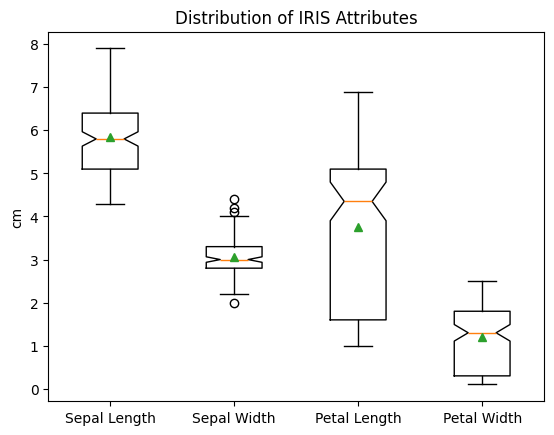

In [9]:
import matplotlib.pyplot as plt

oml.graphics.boxplot(IRIS[:, :4], notch=True, showmeans = True, 
                     labels=['Sepal Length', 'Sepal Width','Petal Length', 'Petal Width'])
plt.title('Distribution of IRIS Attributes')
plt.ylabel('cm');

# Use in-database ML algorithms 

## Compute attribute importance ranking of variables

Using the *IRIS* table, determine which variables (a.k.a., attributes or predictors) are most important in predicting target 'SPECIES'.

Since we're starting with a database table, we split *IRIS* into test and train data sets, and then separate the target from the predictors in the training set.

In the ***setting*** variable, we disable sampling. Note that OML4Py provides parameters to algorithms as name-value pairs. See the OML4Py Users Guide for available options.

Then, we define the attribute importance object, compute attribute importance using function fit, and show the results, which includes the importance ranking.

Notice that petal width is most predictive of the target 'SPECIES'. The importance value produced by this algorithm provides a relative ranking, not an absolute number, to be used to distinguish importance among variables.

In [10]:
from oml import ai

IRIS_train_dat, IRIS_test_dat = IRIS.split() 
IRIS_train_x = IRIS_train_dat.drop('SPECIES')
IRIS_train_y = IRIS_train_dat['SPECIES']

In [11]:
setting = {'ODMS_SAMPLING':'ODMS_SAMPLING_DISABLE'}

ai_obj = ai(**setting)
ai_obj = ai_obj.fit(IRIS_train_x, IRIS_train_y)

ai_obj


Algorithm Name: Attribute Importance

Mining Function: ATTRIBUTE_IMPORTANCE

Settings: 
                   setting name            setting value
0                     ALGO_NAME              ALGO_AI_MDL
1                  ODMS_DETAILS              ODMS_ENABLE
2  ODMS_MISSING_VALUE_TREATMENT  ODMS_MISSING_VALUE_AUTO
3                 ODMS_SAMPLING    ODMS_SAMPLING_DISABLE
4                     PREP_AUTO                       ON

Global Statistics: 
  attribute name  attribute value
0       NUM_ROWS              104

Attributes: 
PETAL_LENGTH
PETAL_WIDTH
SEPAL_LENGTH
SEPAL_WIDTH

Partition: NO

Importance: 

       variable  importance  rank
0   PETAL_WIDTH    0.909653     1
1  PETAL_LENGTH    0.902137     2
2  SEPAL_LENGTH    0.374937     3
3   SEPAL_WIDTH    0.196127     4


In [12]:
# z.show(ai_obj.importance)
display(ai_obj.importance.pull())

,variable,importance,rank
0,PETAL_WIDTH,0.909653,1
1,PETAL_LENGTH,0.902137,2
2,SEPAL_LENGTH,0.374937,3
3,SEPAL_WIDTH,0.196127,4


## Build predictive models

In this example, we set up the data and a ***demo*** cost matrix to build a Random Forest model to predict 'SPECIES' from the *IRIS* table.

Note that we create the cost matrix as a named database table, *RF_COST*.

In [13]:
cost_matrix = [['setosa', 'setosa', 0],
  ['setosa', 'virginica', 0.2],
  ['setosa', 'versicolor', 0.8],
  ['virginica', 'virginica', 0],
  ['virginica', 'setosa', 0.5],
  ['virginica', 'versicolor', 0.5],
  ['versicolor', 'versicolor', 0],
  ['versicolor', 'setosa', 0.4],
  ['versicolor', 'virginica', 0.6]]
  
try:
    oml.drop(table='RF_COST')
except:
    pass

cost_matrix = oml.create(pd.DataFrame(cost_matrix, columns = ['ACTUAL_TARGET_VALUE', 'PREDICTED_TARGET_VALUE', 'COST']), "RF_COST")
cost_matrix.pull().pivot(index='ACTUAL_TARGET_VALUE', 
                         columns='PREDICTED_TARGET_VALUE',values='COST')

PREDICTED_TARGET_VALUE,setosa,versicolor,virginica
ACTUAL_TARGET_VALUE,,,
setosa,0.0,0.8,0.2
versicolor,0.4,0.0,0.6
virginica,0.5,0.5,0.0


### Build a Random Forest model using the Cost Matrix
Build a Random Forest model specifying a maximum tree depth of 4, and display model details.
Note that the model also reports attribute importance.

In [14]:
from oml import rf

rf_mod = rf(tree_term_max_depth = '4')
rf_mod = rf_mod.fit(IRIS_train_x, IRIS_train_y, cost_matrix = cost_matrix)

rf_mod


Algorithm Name: Random Forest

Mining Function: CLASSIFICATION

Target: SPECIES

Settings: 
                    setting name            setting value
0                      ALGO_NAME       ALGO_RANDOM_FOREST
1           CLAS_COST_TABLE_NAME      "OMLUSER"."RF_COST"
2              CLAS_MAX_SUP_BINS                       32
3          CLAS_WEIGHTS_BALANCED                      OFF
4                  ODMS_DEEPTREE    ODMS_DEEPTREE_DISABLE
5                   ODMS_DETAILS              ODMS_ENABLE
6   ODMS_MISSING_VALUE_TREATMENT  ODMS_MISSING_VALUE_AUTO
7               ODMS_RANDOM_SEED                        0
8                  ODMS_SAMPLING    ODMS_SAMPLING_DISABLE
9                      PREP_AUTO                       ON
10                RFOR_NUM_TREES                       20
11           RFOR_SAMPLING_RATIO                       .5
12          TREE_IMPURITY_METRIC       TREE_IMPURITY_GINI
13           TREE_TERM_MAX_DEPTH                        4
14         TREE_TERM_MINPCT_NODE     

## Use the Random Forest model to predict SPECIES

When predicting values, users can include supplemental columns from the original data. This can be particularly useful to compare actual target values against predicted values, or to include unique keys for subsequent row identification. This is necessary since row order is not implicitly maintained on results from the database. This is consistent with how SQL and relational databases provide ordering only if requested by the user via a sort.

In [15]:
pred = rf_mod.predict(IRIS_test_dat.drop('SPECIES'), 
                      supplemental_cols = IRIS_test_dat[:, ['SEPAL_LENGTH', 'SEPAL_WIDTH', 'PETAL_LENGTH', 'SPECIES']])
print("Shape:",pred.shape)
# z.show(pred.head(10))
display(pred.head(10).pull())

Shape: (46, 5)


,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,SPECIES,PREDICTION
0,4.9,3.0,1.4,setosa,setosa
1,4.9,3.1,1.5,setosa,setosa
2,4.8,3.4,1.6,setosa,setosa
3,5.8,4.0,1.2,setosa,setosa
4,5.1,3.5,1.4,setosa,setosa
5,5.0,3.4,1.6,setosa,setosa
6,5.2,3.5,1.5,setosa,setosa
7,5.4,3.4,1.5,setosa,setosa
8,5.0,3.2,1.2,setosa,setosa
9,5.5,3.5,1.3,setosa,setosa


## Generate and display a Confusion Matrix for the predicted results

Using the overloaded ***crosstab*** function, compute the confusion matrix between the actual values in SPECIES and the predictions in the PREDICTION column.

In [16]:
res_ct = pred.crosstab('SPECIES','PREDICTION',pivot=True)
print("Type:",type(res_ct))
print("Columns:",res_ct.columns)

Type: <class 'oml.core.frame.DataFrame'>
Columns: ['SPECIES', 'count_(setosa)', 'count_(versicolor)', 'count_(virginica)']


### Sort the rows
Since columns are sorted by name after pivoting, but the rows are not, sort the rows as a post-processing step.

In [17]:
res_ct.sort_values(by='SPECIES')

      SPECIES  count_(setosa)  count_(versicolor)  count_(virginica)
0      setosa              14                   0                  0
1  versicolor               0                  14                  1
2   virginica               0                   0                 17

## Build an Anomaly Detection Model with SVM

The Support Vector Machine algorithms supports a one-class SVM option for anomaly detection. Predictions with value 0 are considered anomalies. Users can specify various settings, e.g., the outlier rate or the type of SVM kernel functions.

In [18]:
from oml import svm

settings = {'svms_outlier_rate' : 0.05}
svm_mod = svm('anomaly_detection', svms_kernel_function = 'dbms_data_mining.svms_linear',**settings)
svm_mod = svm_mod.fit(IRIS, None)

svm_mod


Algorithm Name: Support Vector Machine

Mining Function: ANOMALY_DETECTION

Settings: 
                   setting name                 setting value
0                     ALGO_NAME  ALGO_SUPPORT_VECTOR_MACHINES
1                  ODMS_DETAILS                   ODMS_ENABLE
2  ODMS_MISSING_VALUE_TREATMENT       ODMS_MISSING_VALUE_AUTO
3                 ODMS_SAMPLING         ODMS_SAMPLING_DISABLE
4                     PREP_AUTO                            ON
5           SVMS_CONV_TOLERANCE                         .0001
6          SVMS_KERNEL_FUNCTION                   SVMS_LINEAR
7             SVMS_OUTLIER_RATE                          0.05

Computed Settings: 
              setting name    setting value
0  ODMS_EXPLOSION_MIN_SUPP                1
1   SVMS_COMPLEXITY_FACTOR               10
2      SVMS_NUM_ITERATIONS               30
3              SVMS_SOLVER  SVMS_SOLVER_IPM

Global Statistics: 
  attribute name attribute value
0      CONVERGED             YES
1     ITERATIONS          

### Predict which cases are anomalies
We can predict which cases are anomalies using the ***predict*** function. If ***proba*** is set to True, we will get the probability associated with the prediction.

In [19]:
res = svm_mod.predict(IRIS, proba = True)
print("Type:", type(res))
# z.show(res.head(4))
display(res.head(4).pull())

Type: <class 'oml.core.frame.DataFrame'>


,PREDICTION,PROBABILITY
0,1,0.606117
1,1,0.570993
2,1,0.554015
3,1,0.556129


### Assess how many anomalies were identified
Let's assess how many anomalies were identified. Here we see that roughly 5% are reported as indicated from our setting above.

In [20]:
anomalies = res[res['PREDICTION'] == 0]

print("Type:", type(anomalies))
print("IRIS Shape:", IRIS.shape)
print("Anomalies Shape:", anomalies.shape)
# z.show(anomalies.head(10))
display(anomalies.head(10).pull())

Type: <class 'oml.core.frame.DataFrame'>
IRIS Shape: (150, 5)
Anomalies Shape: (8, 2)


,PREDICTION,PROBABILITY
0,0,0.555111
1,0,0.563158
2,0,0.535123
3,0,0.603485
4,0,0.545434
5,0,0.504524
6,0,0.545612
7,0,0.527500


## Obtain attribute importance for supervised models using machine learning explainability (MLX)

Machine Learning Explainability (MLX) aids in explaining machine learning model behavior, by providing model-agnostic explanations for classification and regression algorithms. This treats the model as a black box instead of using properties from the model itself to guide the explanation. The technique used is called _Global Permutation Importance_ (GPI).

Read more about it in <a href="https://docs.oracle.com/en/database/oracle/machine-learning/oml4py/2/mlpug/model-explainability.html" target="_blank">the documentation for Model Explainability (MLX) </a>

In [21]:
import oml
from oml.mlx import GlobalFeatureImportance

IRIS_model = oml.dt().fit(IRIS_train_x, IRIS_train_y)
IRIS_exp = GlobalFeatureImportance(mining_function='classification',score_metric='f1_weighted',random_state=42, parallel=4)
IRIS_res = IRIS_exp.explain(IRIS_model, IRIS_train_x, IRIS_train_y, n_iter=8)
IRIS_res

Global Feature Importance: 
	[0] PETAL_LENGTH: Value: 0.4409, Error: 0.0287
	[1] PETAL_WIDTH: Value: 0.2937, Error: 0.0488
	[2] SEPAL_LENGTH: Value: 0.0000, Error: 0.0000
	[3] SEPAL_WIDTH: Value: 0.0000, Error: 0.0000

# End of Script